## Author
Name: Zhihao Cui <br>
Institute: School of Mathematics and Statistics <br>
No: 20233002662

In [4]:
from __future__ import print_function
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [5]:
# 固定随机种子以保证结果可复现
RANDOM_STATE = 42


[异常检测结果对比]
            method  pred_outliers  precision  recall     f1    auc
LocalOutlierFactor             30     0.8000  0.8000 0.8000 0.9683
   IsolationForest             30     0.7667  0.7667 0.7667 0.9721
       OneClassSVM             40     0.5750  0.7667 0.6571 0.9272
  EllipticEnvelope             30     0.5000  0.5000 0.5000 0.8607


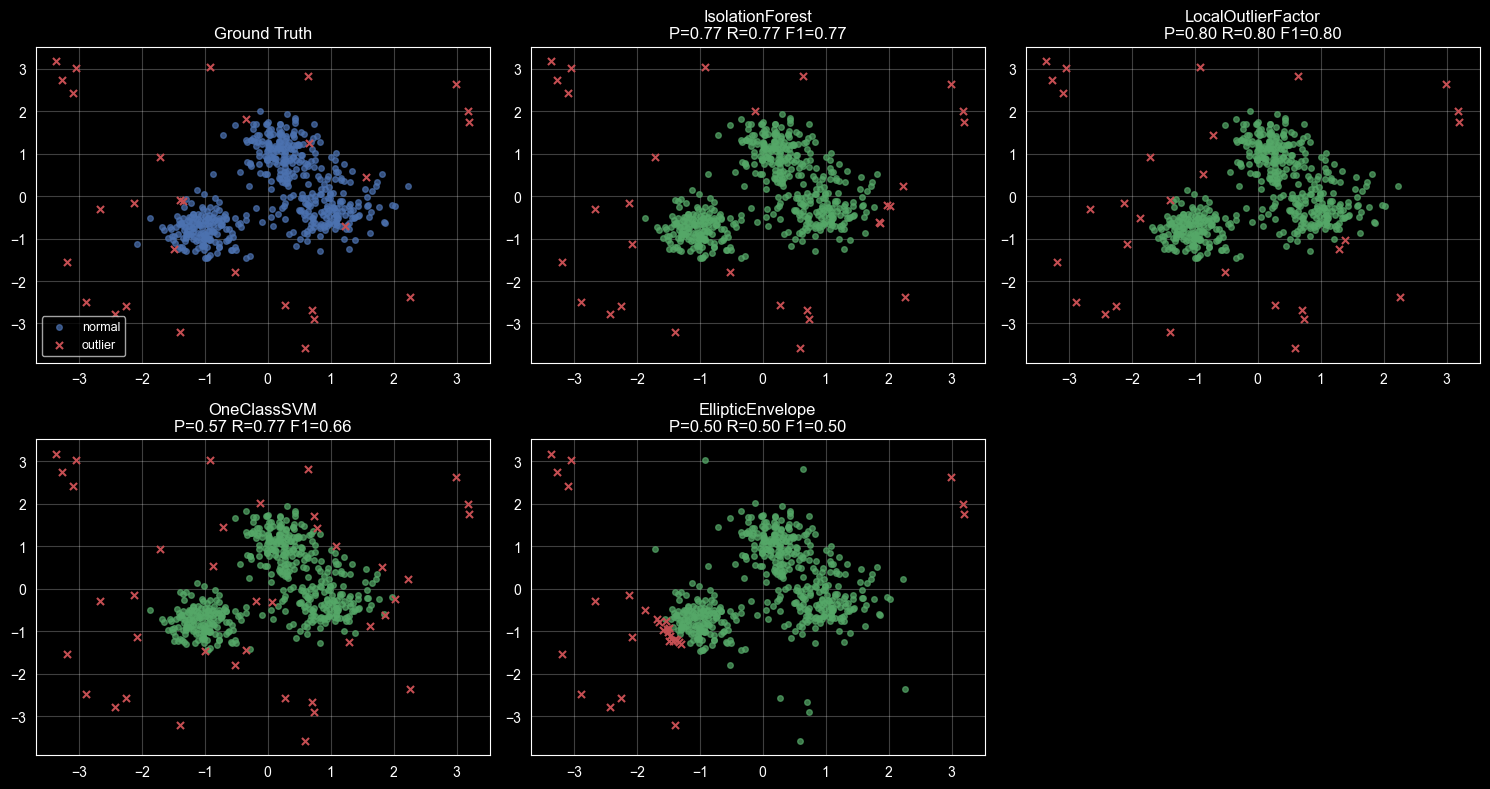

In [6]:
def build_dataset(n_inliers=500, n_outliers=30):
    """构造二维教学数据：正常点（聚类生成）+ 人工异常点（均匀随机）。"""
    # 生成3个簇的正常样本
    x_in, _ = make_blobs(
        n_samples=n_inliers,
        centers=[(-2.0, -1.0), (2.0, 0.0), (0.5, 2.5)],
        cluster_std=[0.65, 0.85, 0.7],
        random_state=RANDOM_STATE,
    )

    # 在较大范围内均匀生成异常点
    rng = np.random.RandomState(RANDOM_STATE)
    x_out = rng.uniform(low=-7.0, high=7.0, size=(n_outliers, 2))

    x = np.vstack([x_in, x_out])
    y_true = np.hstack([np.zeros(len(x_in), dtype=int), np.ones(len(x_out), dtype=int)])  # 1=异常

    # 标准化所有特征，使不同方法对尺度不敏感
    x = StandardScaler().fit_transform(x)
    return x, y_true


def metrics_from_pred(y_true, y_pred_binary, score=None):
    """计算 precision, recall, f1；若提供异常分数（越大越异常）则额外计算 AUC。"""
    m = {}
    m["precision"] = precision_score(y_true, y_pred_binary, zero_division=0)
    m["recall"] = recall_score(y_true, y_pred_binary, zero_division=0)
    m["f1"] = f1_score(y_true, y_pred_binary, zero_division=0)

    if score is None:
        m["auc"] = np.nan
    else:
        try:
            m["auc"] = roc_auc_score(y_true, score)
        except Exception:
            m["auc"] = np.nan
    return m


def run_isolation_forest(x, contamination):
    model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=RANDOM_STATE,
    )
    pred = model.fit_predict(x)          # 返回 1（正常） 或 -1（异常）
    y_pred = (pred == -1).astype(int)

    # decision_function 返回正值表示正常，取负后越大表示越异常
    score = -model.decision_function(x)
    return y_pred, score


def run_lof(x, contamination, n_neighbors=20):
    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=contamination,
    )
    pred = model.fit_predict(x)          # 1 正常, -1 异常
    y_pred = (pred == -1).astype(int)

    # negative_outlier_factor_ 越小越异常，取负后越大越异常
    score = -model.negative_outlier_factor_
    return y_pred, score


def run_one_class_svm(x, contamination):
    # nu 的上限为 0.5，下限略高于 contamination，避免极端值
    nu = max(0.001, min(0.5, contamination + 0.02))
    model = OneClassSVM(kernel="rbf", gamma="scale", nu=nu)
    pred = model.fit_predict(x)          # 1 正常, -1 异常
    y_pred = (pred == -1).astype(int)

    # decision_function 值越大越正常，取负后越大越异常
    score = -model.decision_function(x).ravel()
    return y_pred, score


def run_elliptic_envelope(x, contamination):
    model = EllipticEnvelope(
        contamination=contamination,
        random_state=RANDOM_STATE,
    )
    pred = model.fit_predict(x)          # 1 正常, -1 异常
    y_pred = (pred == -1).astype(int)

    score = -model.decision_function(x)
    return y_pred, score


def evaluate_all(x, y_true):
    """对所有异常检测方法进行训练、预测和指标计算。"""
    contamination = float(np.mean(y_true))   # 真实异常比例
    results = []

    methods = [
        ("IsolationForest", run_isolation_forest),
        ("LocalOutlierFactor", run_lof),
        ("OneClassSVM", run_one_class_svm),
        ("EllipticEnvelope", run_elliptic_envelope),
    ]

    for name, fn in methods:
        y_pred, score = fn(x, contamination)
        m = metrics_from_pred(y_true, y_pred, score=score)
        results.append({
            "method": name,
            "y_pred": y_pred,
            "score": score,
            "precision": m["precision"],
            "recall": m["recall"],
            "f1": m["f1"],
            "auc": m["auc"],
            "n_pred_outlier": int(y_pred.sum()),
        })

    return results


def print_table(results):
    """将结果格式化为表格并打印，按 F1 降序排列。"""
    df = pd.DataFrame([
        {
            "method": r["method"],
            "pred_outliers": r["n_pred_outlier"],
            "precision": round(r["precision"], 4),
            "recall": round(r["recall"], 4),
            "f1": round(r["f1"], 4),
            "auc": round(r["auc"], 4) if np.isfinite(r["auc"]) else np.nan,
        }
        for r in results
    ])

    df = df.sort_values(["f1", "auc", "precision"], ascending=[False, False, False]).reset_index(drop=True)
    print("\n[异常检测结果对比]")
    print(df.to_string(index=False))


def plot_results(x, y_true, results):
    """绘制真实标签及各方法预测结果散点图，便于直观对比。"""
    total = len(results) + 1
    ncols = 3
    nrows = int(np.ceil(total / float(ncols)))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    # 第一子图：真实标签
    ax0 = axes[0]
    ax0.scatter(x[y_true == 0, 0], x[y_true == 0, 1], s=16, c="#4C72B0", alpha=0.7, label="normal")
    ax0.scatter(x[y_true == 1, 0], x[y_true == 1, 1], s=26, c="#C44E52", marker="x", label="outlier")
    ax0.set_title("Ground Truth")
    ax0.legend(loc="best", fontsize=9)
    ax0.grid(alpha=0.25)

    # 其余子图：每种方法的预测结果
    for i, r in enumerate(results, start=1):
        ax = axes[i]
        yp = r["y_pred"]

        ax.scatter(x[yp == 0, 0], x[yp == 0, 1], s=16, c="#55A868", alpha=0.7, label="pred normal")
        ax.scatter(x[yp == 1, 0], x[yp == 1, 1], s=26, c="#C44E52", marker="x", label="pred outlier")

        ax.set_title(
            "{}\nP={:.2f} R={:.2f} F1={:.2f}".format(
                r["method"], r["precision"], r["recall"], r["f1"]
            )
        )
        ax.grid(alpha=0.25)

    # 删除多余的子图（若子图数量多于实际需要）
    for j in range(total, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


def main():
    parser = argparse.ArgumentParser(description="异常检测教学脚本（Python 3.7+ 兼容）")
    parser.add_argument("--n_inliers", type=int, default=500)
    parser.add_argument("--n_outliers", type=int, default=30)
    parser.add_argument("--no_plot", action="store_true", help="仅打印结果，不画图")
    # 使用 parse_known_args() 忽略 Jupyter 等环境传入的未知参数
    args, unknown = parser.parse_known_args()

    x, y_true = build_dataset(n_inliers=args.n_inliers, n_outliers=args.n_outliers)
    results = evaluate_all(x, y_true)
    print_table(results)

    if not args.no_plot:
        plot_results(x, y_true, results)


if __name__ == "__main__":
    main()